In [1]:
# Import & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import time
import torch

BASE_PATH = r'D:\Jupyter\MLOps_Gold\\'
DATA_PATH = BASE_PATH + 'data\\'
VISUAL_PATH = BASE_PATH + 'visuals\\'
MODEL_PATH = BASE_PATH + 'models\\'

os.makedirs(VISUAL_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Setup selesai!")
print(f"Device: {device}")

D:\Jupyter\env_gpu\lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Setup selesai!
Device: cuda


In [2]:
# Load Data & Split
df_norm = pd.read_parquet(DATA_PATH + 'data_clean_normalized.parquet')
feature_cols = [c for c in df_norm.columns if c != 'Target']

train_size = int(len(df_norm) * 0.7)
val_size = int(len(df_norm) * 0.15)

train_df = df_norm.iloc[:train_size]
val_df = df_norm.iloc[train_size:train_size+val_size]
test_df = df_norm.iloc[train_size+val_size:]

print(f"Data berhasil dimuat!")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Data berhasil dimuat!
Train: 7,966,901 | Val: 1,707,193 | Test: 1,707,194


In [3]:
# Install & Import Darts
import subprocess
subprocess.run(['pip', 'install', '-q', 'u8darts[torch]'])

from darts import TimeSeries
from darts.models import NHiTSModel
print("Darts berhasil diimport!")

D:\Jupyter\env_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


Darts berhasil diimport!


In [4]:
# Persiapan Data Format Darts
train_series = TimeSeries.from_dataframe(
    train_df.reset_index(), time_col='Date', value_cols='Target', freq='min')

val_series = TimeSeries.from_dataframe(
    val_df.reset_index(), time_col='Date', value_cols='Target', freq='min')

test_series = TimeSeries.from_dataframe(
    test_df.reset_index(), time_col='Date', value_cols='Target', freq='min')

train_cov = TimeSeries.from_dataframe(
    train_df.reset_index(), time_col='Date', value_cols=feature_cols, freq='min')

val_cov = TimeSeries.from_dataframe(
    val_df.reset_index(), time_col='Date', value_cols=feature_cols, freq='min')

test_cov = TimeSeries.from_dataframe(
    test_df.reset_index(), time_col='Date', value_cols=feature_cols, freq='min')

print(f"Data siap untuk Darts!")
print(f"Train: {len(train_series)} | Val: {len(val_series)} | Test: {len(test_series)}")

Data siap untuk Darts!
Train: 7966901 | Val: 1707193 | Test: 1707194


In [ ]:
# Build & Train N-HiTS
model_nhits = NHiTSModel(
    input_chunk_length=10,
    output_chunk_length=1,
    num_stacks=3,
    num_blocks=1,
    num_layers=2,
    layer_widths=512,
    n_epochs=5,
    batch_size=256,
    random_state=42,
    pl_trainer_kwargs={
        'accelerator': device,
        'enable_progress_bar': True
    }
)

start_time = time.time()

model_nhits.fit(
    series=train_series,
    past_covariates=train_cov,
    val_series=val_series,
    val_past_covariates=val_cov,
    verbose=True
)

elapsed = time.time() - start_time
print(f"\nTraining N-HiTS selesai: {elapsed/60:.1f} menit")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 1.4 M  | train
------------

Epoch 0: 100%|██████████████████████████████████████████████| 31121/31121 [17:23<00:00, 29.83it/s, train_loss=0.000552]
Validation: |                                                                                    | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:  91%|███████████████████████████████████████████████▎    | 6072/6669 [01:00<00:05, 100.94it/s]


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Epoch 2: 100%|████████████████████████████| 31121/31121 [16:59<00:00, 30.54it/s, train_loss=0.00174, val_loss=0.000801]
Validation: |                                                                                    | 0/? [00:00<?, ?it/s]
Epoch 4:  95%|█████████████████████████▊ | 29717/31121 [15:20<00:43, 32.29it/s, train_loss=0.000548, val_loss=0.000736]

In [6]:
# Prediksi Test Set
print("Prediksi test set...")

full_series = train_series.append(val_series)
full_cov = train_cov.append(val_cov)

pred_series = model_nhits.historical_forecasts(
    series=full_series.append(test_series),
    past_covariates=full_cov.append(test_cov),
    start=test_series.start_time(),
    forecast_horizon=1,
    stride=1,
    retrain=False,
    verbose=True
)

y_pred_nhits = pred_series.values().flatten()
y_test = test_series.values().flatten()[:len(y_pred_nhits)]

print(f"Prediksi selesai!")
print(f"Shape prediksi: {y_pred_nhits.shape}")
print(f"Shape aktual  : {y_test.shape}")

Predicting DataLoader 0: 100%|█████████████████████████████████████████████████████| 6669/6669 [04:06<00:00, 27.01it/s]
Prediksi selesai!
Shape prediksi: (1707194,)
Shape aktual  : (1707194,)


In [7]:
# Evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred_nhits)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_nhits))

mask = np.abs(y_test) > 0.01
mape = np.mean(np.abs((y_test[mask] - y_pred_nhits[mask]) / y_test[mask])) * 100
da = np.mean(np.sign(np.diff(y_test)) == np.sign(np.diff(y_pred_nhits))) * 100

print("=" * 50)
print("EVALUASI N-HiTS")
print("=" * 50)
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.4f}%")
print(f"Directional Accuracy: {da:.2f}%")
print("=" * 50)

EVALUASI N-HiTS
MAE  : 0.012949
RMSE : 0.026387
MAPE : 6.0959%
Directional Accuracy: 55.27%


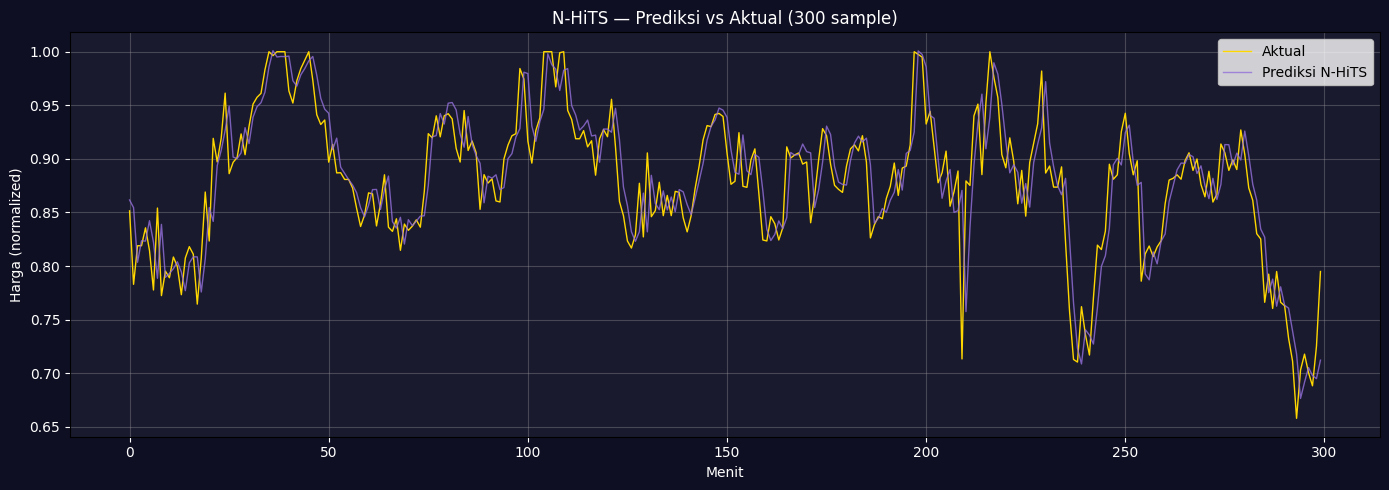

Visualisasi prediksi berhasil!


In [8]:
# Visualisasi Prediksi vs Aktual
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test[:300], label='Aktual', color='gold', linewidth=1)
ax.plot(y_pred_nhits[:300], label='Prediksi N-HiTS', color='mediumpurple', linewidth=1, alpha=0.8)

ax.set_title('N-HiTS — Prediksi vs Aktual (300 sample)', color='white')
ax.set_xlabel('Menit', color='white')
ax.set_ylabel('Harga (normalized)', color='white')
ax.legend()
ax.set_facecolor('#1a1a2e')
ax.grid(True, alpha=0.3)
ax.tick_params(colors='white')

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'nhits_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi prediksi berhasil!")

In [9]:
# Plot Training History
import glob

log_files = glob.glob(r'D:\Jupyter\lightning_logs\**\metrics.csv', recursive=True)

if log_files:
    metrics_df = pd.read_csv(log_files[-1])
    fig, ax = plt.subplots(figsize=(10, 5))

    if 'train_loss' in metrics_df.columns:
        train_loss = metrics_df[metrics_df['train_loss'].notna()]['train_loss']
        ax.plot(train_loss.values, label='Train Loss', color='gold')

    if 'val_loss' in metrics_df.columns:
        val_loss = metrics_df[metrics_df['val_loss'].notna()]['val_loss']
        ax.plot(val_loss.values, label='Val Loss', color='steelblue')

    ax.set_title('N-HiTS — Training History', color='white')
    ax.set_xlabel('Steps', color='white')
    ax.set_ylabel('Loss', color='white')
    ax.legend()
    ax.set_facecolor('#1a1a2e')
    ax.grid(True, alpha=0.3)
    ax.tick_params(colors='white')

    fig.patch.set_facecolor('#0f0f23')
    plt.tight_layout()
    plt.savefig(VISUAL_PATH + 'nhits_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Training history berhasil!")
else:
    print("Log tidak ditemukan, skip plot history.")

Log tidak ditemukan, skip plot history.


In [10]:
# Save Model & Hasil
model_nhits.save(MODEL_PATH + 'model_nhits.pt')
print("Model N-HiTS disimpan sebagai .pt")

results_nhits = {
    'Model': 'N-HiTS',
    'MAE': float(mae),
    'RMSE': float(rmse),
    'MAPE (%)': float(mape),
    'Directional Accuracy (%)': float(da)
}

with open(MODEL_PATH + 'results_nhits.json', 'w') as f:
    json.dump(results_nhits, f)

print("=" * 50)
print("SUMMARY N-HiTS")
print("=" * 50)
print(f"Model    : N-HiTS (input=10, output=1, stacks=3)")
print(f"MAE      : {mae:.6f}")
print(f"RMSE     : {rmse:.6f}")
print(f"MAPE     : {mape:.4f}%")
print(f"Dir. Acc : {da:.2f}%")
print(f"\nSemua file disimpan di: {MODEL_PATH}")
print("=" * 50)

Model N-HiTS disimpan sebagai .pt
SUMMARY N-HiTS
Model    : N-HiTS (input=10, output=1, stacks=3)
MAE      : 0.012949
RMSE     : 0.026387
MAPE     : 6.0959%
Dir. Acc : 55.27%

Semua file disimpan di: D:\Jupyter\MLOps_Gold\\models\
